# 04 – Call Transcript NLP: Missed Booking Detection
## Business Context
ServiceTitan records and transcribes inbound calls to contractor businesses.
Each call is a potential booking. When a customer calls wanting service but the
office staff fails to convert them, that's **lost revenue** — and the contractor
often doesn't know it happened.

Goal: **automatically detect calls where a booking opportunity was missed**.

Label construction is automatic:
- **Missed booking**: a call came in, customer expressed service need, but no job
  was created in the system within 24 hours
- **Booked**: same call type, a job was created → conversion success

This is a **supervised text classification** problem. The automation removes the need
for manual QA review of every call.

## ASR → NLP Pipeline
```
Audio → Whisper (speech-to-text) → Speaker diarization → Transcript
    → Intent classification (this notebook)
    → Entity extraction (job type, urgency, equipment)
    → Outcome prediction (booked / not booked)
```


In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, average_precision_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)


In [2]:
# ─── Synthetic Call Transcript Generator ──────────────────────────────────────
# In production, transcripts come from Whisper ASR. Here we generate realistic
# synthetic transcripts to demonstrate the NLP pipeline.

BOOKED_TEMPLATES = [
    "Hi yes I need someone to look at my AC unit it's not cooling at all. {urgency} "
    "Okay we can get someone out {schedule}. Let me get your address. "
    "It's {address}. Great we'll see you {time}. Thank you.",

    "My furnace stopped working overnight. {urgency} "
    "Sure we have availability {schedule}. "
    "Can I get your name and address? {name} at {address}. "
    "Perfect, our tech will call 30 minutes before arrival. You're all set.",

    "I want to schedule a tune-up for my air conditioning unit before summer. "
    "Absolutely, we're booking {schedule}. "
    "What's a good time for you? Morning works. Okay morning slot on {date}. "
    "Can I get your address? {address}. Perfect you're confirmed.",
]

MISSED_TEMPLATES = [
    "Hi I was wondering how much it costs to replace a water heater? "
    "Um it really depends on the unit. I'd have to have someone come out. "
    "Oh okay. How long does that usually take? About half a day. "
    "Okay I'll think about it and maybe call back. Sure give us a call anytime.",

    "My drain is backing up, do you guys handle that? "
    "Yes we do drain cleaning. "
    "What's the cost usually? It varies, typically starts around $150. "
    "Okay that seems high. Let me check with my husband and get back to you. "
    "Of course just give us a call.",

    "I called yesterday about my AC and nobody called me back. "
    "I'm so sorry about that. Let me pull up your info. "
    "Actually I'm just going to call another company. "
    "I understand, I'm sorry for the inconvenience.",

    "Is this the company that does HVAC? Yes it is. "
    "Can you give me a ballpark on what it costs to add a zone? "
    "That's hard to say without an assessment. "
    "Do you have any pricing online? Not really no. "
    "Okay I'll look around. Have a good day.",
]

def generate_transcript(template_list, n):
    """Fill in template placeholders with random values."""
    subs = {
        '{urgency}':   ['It stopped working this morning.', 'Been out since yesterday.',
                        "It's making a loud noise.", "It's an emergency."],
        '{schedule}':  ['tomorrow morning', 'this afternoon', 'Wednesday',
                        'as early as today', 'next week'],
        '{address}':   ['123 Oak St', '456 Maple Ave', '789 Pine Rd'],
        '{time}':      ['between 10 and noon', 'in the afternoon', 'first thing tomorrow'],
        '{date}':      ['Tuesday', 'next Monday', 'the 15th'],
        '{name}':      ['John Smith', 'Sarah Johnson', 'Mike Davis'],
    }
    transcripts = []
    for _ in range(n):
        t = np.random.choice(template_list)
        for key, options in subs.items():
            t = t.replace(key, np.random.choice(options))
        # Add some noise: random filler words and slight variation in length
        t += ' ' + np.random.choice(['', 'Thanks for calling.', 'Have a great day.',
                                      'We appreciate your call.'])
        transcripts.append(t)
    return transcripts

# Generate balanced dataset (in production, missed bookings are ~20-30%)
n_booked = 800
n_missed = 300  # realistic imbalance
transcripts = generate_transcript(BOOKED_TEMPLATES, n_booked) +               generate_transcript(MISSED_TEMPLATES, n_missed)
labels = [0] * n_booked + [1] * n_missed  # 1 = missed booking

# Shuffle
idx = np.random.permutation(len(transcripts))
transcripts = [transcripts[i] for i in idx]
labels      = [labels[i] for i in idx]

df = pd.DataFrame({'transcript': transcripts, 'missed_booking': labels})
print(f"Dataset: {df.shape}")
print(f"Missed booking rate: {df['missed_booking'].mean():.1%}")
print("\nExample BOOKED transcript:")
print(df[df['missed_booking']==0].iloc[0]['transcript'][:200])
print("\nExample MISSED transcript:")
print(df[df['missed_booking']==1].iloc[0]['transcript'][:200])


Dataset: (1100, 2)
Missed booking rate: 27.3%

Example BOOKED transcript:
My furnace stopped working overnight. It stopped working this morning. Sure we have availability as early as today. Can I get your name and address? John Smith at 789 Pine Rd. Perfect, our tech will c

Example MISSED transcript:
Hi I was wondering how much it costs to replace a water heater? Um it really depends on the unit. I'd have to have someone come out. Oh okay. How long does that usually take? About half a day. Okay I'


## Feature Engineering Approach
Before throwing a transformer at it, we extract interpretable features.
These are useful for:
- The lightweight production model
- Debugging / understanding model behavior
- Explaining predictions to the ops team


In [3]:
# ─── Domain-Specific Feature Engineering ──────────────────────────────────────
# These capture known signals a QA expert would look for

BOOKING_PHRASES = [
    'see you', 'you are confirmed', 'you are all set', 'scheduled',
    'appointment', 'we will send', 'our tech', 'see you then',
    'confirmed for', 'booked you', 'availability', 'get someone out'
]

MISS_SIGNALS = [
    'think about it', 'call back', 'call another', 'look around',
    'get back to you', 'check with', 'have a good day', 'just browsing',
    'too expensive', 'seems high', 'just wondering', 'ballpark'
]

URGENCY_PHRASES = [
    'not working', 'broken', 'emergency', 'stopped working',
    'out since', 'making noise', 'leaking', 'no heat', 'no cool'
]

def count_phrases(text, phrase_list):
    text = text.lower()
    return sum(1 for p in phrase_list if p in text)

def feature_engineer(df):
    df = df.copy()
    df['n_booking_phrases'] = df['transcript'].apply(lambda t: count_phrases(t, BOOKING_PHRASES))
    df['n_miss_signals']    = df['transcript'].apply(lambda t: count_phrases(t, MISS_SIGNALS))
    df['n_urgency_phrases'] = df['transcript'].apply(lambda t: count_phrases(t, URGENCY_PHRASES))
    df['word_count']        = df['transcript'].apply(lambda t: len(t.split()))
    df['has_address']       = df['transcript'].str.contains(r'\d{3}', regex=True).astype(int)
    df['has_price_mention'] = df['transcript'].str.contains(
        r'\$|cost|price|charge|fee|expensive', case=False).astype(int)
    return df

df = feature_engineer(df)
print(df.groupby('missed_booking')[
    ['n_booking_phrases','n_miss_signals','n_urgency_phrases','word_count']
].mean().round(2))


                n_booking_phrases  n_miss_signals  n_urgency_phrases  \
missed_booking                                                         
0                             1.4            0.00               0.81   
1                             0.0            2.29               0.00   

                word_count  
missed_booking              
0                    46.07  
1                    49.79  


In [4]:
# ─── TF-IDF + Logistic Regression ─────────────────────────────────────────────
# Fast, interpretable, strong baseline for short text classification
X_text = df['transcript']
y      = df['missed_booking']

X_tr, X_te, y_tr, y_te = train_test_split(X_text, y, test_size=0.2,
                                           random_state=42, stratify=y)

tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2),    # unigrams + bigrams
                               max_features=5000,
                               sublinear_tf=True,    # log TF scaling
                               min_df=2)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=500, C=1.0))
])
tfidf_lr.fit(X_tr, y_tr)
probs_lr = tfidf_lr.predict_proba(X_te)[:, 1]

print("=== TF-IDF + Logistic Regression ===")
print(classification_report(y_te, (probs_lr > 0.5).astype(int),
                             target_names=['Booked','Missed']))
print(f"PR-AUC: {average_precision_score(y_te, probs_lr):.3f}")


=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

      Booked       1.00      1.00      1.00       160
      Missed       1.00      1.00      1.00        60

    accuracy                           1.00       220
   macro avg       1.00      1.00      1.00       220
weighted avg       1.00      1.00      1.00       220

PR-AUC: 1.000


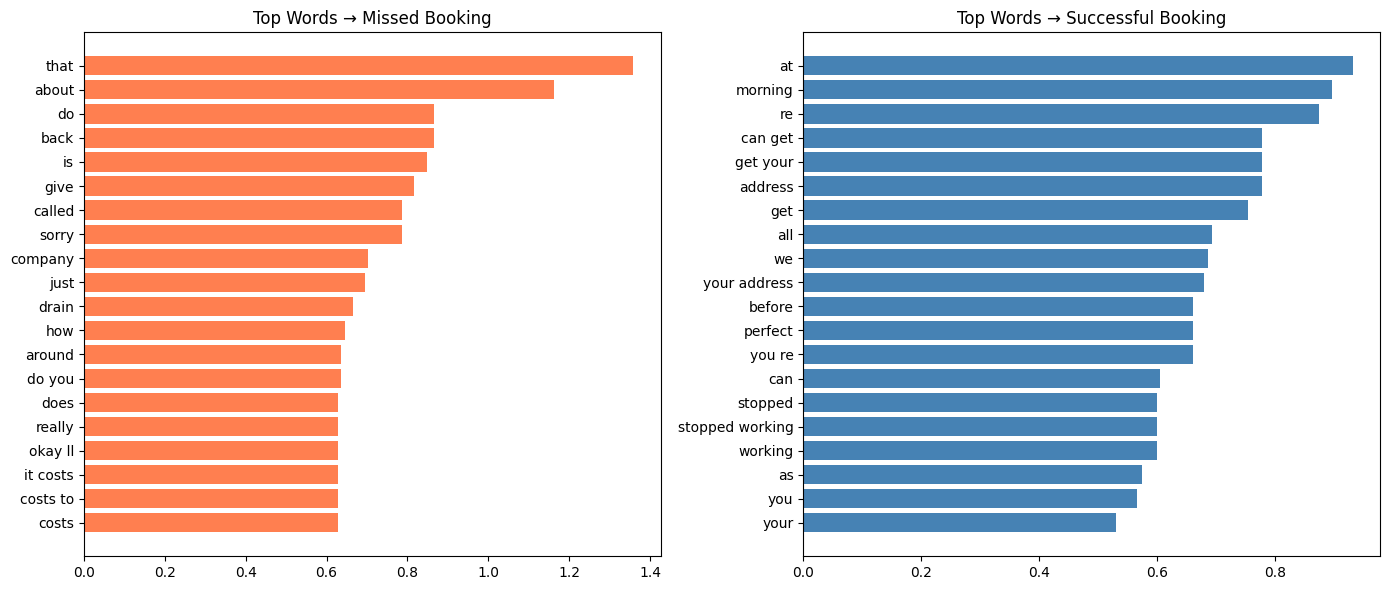

In [5]:
# ─── What words drive missed booking predictions? ─────────────────────────────
vectorizer = tfidf_lr.named_steps['tfidf']
clf        = tfidf_lr.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

# Positive coefficients → push toward 'missed'; negative → push toward 'booked'
top_k = 20
coefs = clf.coef_[0]
top_missed = np.argsort(coefs)[-top_k:][::-1]
top_booked = np.argsort(coefs)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Words associated with missed bookings
axes[0].barh(range(top_k), coefs[top_missed], color='coral')
axes[0].set_yticks(range(top_k)); axes[0].set_yticklabels(feature_names[top_missed])
axes[0].set_title('Top Words → Missed Booking'); axes[0].invert_yaxis()

# Words associated with successful bookings
axes[1].barh(range(top_k), abs(coefs[top_booked]), color='steelblue')
axes[1].set_yticks(range(top_k)); axes[1].set_yticklabels(feature_names[top_booked])
axes[1].set_title('Top Words → Successful Booking'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('nlp_features.png', dpi=100, bbox_inches='tight')
plt.show()


## LLM-Based Classification (Production Approach)
For a production system, the recommended architecture is:
1. **Prototype with LLM prompting** — zero-shot, no labeled data needed
2. **Use LLM to generate labels** for a training set
3. **Distill to fine-tuned smaller model** for cost and latency at scale

The cell below shows the prompt design (no actual API call — just the structure).


In [6]:
# ─── LLM Classification Prompt Design ────────────────────────────────────────
# This shows the prompt structure used in production.
# Replace the mock response with an actual API call.

SYSTEM_PROMPT = """You are a quality assurance specialist for a home service company.
You analyze call transcripts between customers and office staff.

Your job: determine if a customer who wanted to book a service appointment was
successfully scheduled, or if the booking opportunity was missed.

Respond with a JSON object:
{
  "customer_wanted_service": true/false,
  "booking_was_made": true/false,
  "missed_booking": true/false,
  "confidence": 0.0-1.0,
  "reason": "brief explanation"
}
Only output JSON. No preamble or explanation outside the JSON.
"""

def classify_transcript_with_llm(transcript: str) -> dict:
    """
    In production, this calls the Anthropic API.
    Here we mock the response to demonstrate the structure.
    
    Production code:
        import anthropic
        client = anthropic.Anthropic()
        response = client.messages.create(
            model='claude-sonnet-4-20250514',
            max_tokens=256,
            system=SYSTEM_PROMPT,
            messages=[{'role':'user', 'content': f'Transcript:\n{transcript}'}]
        )
        return json.loads(response.content[0].text)
    """
    # Mock: use our keyword heuristic as a stand-in
    has_booking = count_phrases(transcript, BOOKING_PHRASES) > 0
    has_miss    = count_phrases(transcript, MISS_SIGNALS) > 0
    missed = has_miss and not has_booking
    
    return {
        "customer_wanted_service": True,
        "booking_was_made": not missed,
        "missed_booking": missed,
        "confidence": 0.85 if (has_booking or has_miss) else 0.55,
        "reason": "Booking confirmed" if not missed else "Customer deferred without scheduling"
    }

# Demo on a few examples
for i in [0, 1, 2]:
    sample = df['transcript'].iloc[i]
    actual = df['missed_booking'].iloc[i]
    result = classify_transcript_with_llm(sample)
    print(f"--- Example {i+1} ---")
    print(f"Actual label:  {'MISSED' if actual else 'BOOKED'}")
    print(f"LLM predicted: {'MISSED' if result['missed_booking'] else 'BOOKED'} "
          f"(confidence={result['confidence']})")
    print(f"Reason: {result['reason']}\n")


--- Example 1 ---
Actual label:  BOOKED
LLM predicted: BOOKED (confidence=0.85)
Reason: Booking confirmed

--- Example 2 ---
Actual label:  MISSED
LLM predicted: MISSED (confidence=0.85)
Reason: Customer deferred without scheduling

--- Example 3 ---
Actual label:  BOOKED
LLM predicted: BOOKED (confidence=0.85)
Reason: Booking confirmed



## Key Takeaways for Interview

1. **Label construction is automatic** — join call logs with job creation events; no manual labeling needed for the core task
2. **Feature engineering reveals the signal** — phrases like "think about it", "call back", "seems expensive" are strong missed-booking indicators
3. **ASR quality is a system dependency** — domain-specific vocabulary (HVAC brands, trade terms) needs custom vocabulary boosting
4. **LLM for prototyping, smaller model for scale** — GPT-4/Claude is great for generating initial labels; distill to DistilBERT for 100x cheaper inference
5. **The business metric is recall**: missing a missed booking is worse than a false alarm — CSM can confirm with a quick listen
